# Notebook 03 — Stage S: Simulation (R3)

This notebook implements **Stage S** of the pipeline (Revision 3):
- 4 conditions × 3 demand levels × 50 replications = **600 simulation runs**.

**Conditions** (all LP arms use the Factor forecast):
- **Random** — lower-bound reference
- **Greedy** — Nearest-Feasible Greedy (no plan)
- **Static-LP** — LP plan committed at t=0
- **MPC-LP** — rolling-horizon LP, re-solved hourly with current inventory + 80%-quantile hedge

**Demand stress sweep:** 0.7×, 1.0×, 1.3× baseline arrivals — shows the operating curve.

CRN seeds shared across all 4 conditions at every demand level.

**Prerequisite:** `notebook_01_forecasting.ipynb` and `notebook_02_optimization.ipynb`.

In [1]:
import sys
from pathlib import Path

repo_root = Path().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from src.utils.config_loader import load_config
from src.experiment.runner import ExperimentRunner

print("Imports successful")

Imports successful


## 1. Load configs

In [2]:
configs = {
    "data_gen":   load_config(repo_root / "config" / "sarima.yaml")["data_gen"],
    "simulation": load_config(repo_root / "config" / "simulation.yaml"),
    "network":    load_config(repo_root / "config" / "network.yaml"),
    "lp":         load_config(repo_root / "config" / "lp.yaml"),
}
exp_cfg = load_config(repo_root / "config" / "experiment.yaml")
configs["mpc"] = exp_cfg["mpc"]

n_replications = int(exp_cfg["experiment"]["n_replications"])
demand_scales  = list(exp_cfg["experiment"]["demand_scales"])

print(f"n_replications: {n_replications}")
print(f"demand_scales:  {demand_scales}")
print(f"MPC config:     {configs['mpc']}")

n_replications: 50
demand_scales:  [0.7, 1.0, 1.3]
MPC config:     {'horizon_hours': 12, 'replan_interval_hours': 1.0, 'demand_quantile': 0.65}


## 2. Run the full stress sweep — 4 conditions × 3 demand levels × 50 reps

Estimated runtime: 8–15 minutes.

In [3]:
runner = ExperimentRunner(configs)

results_by_demand = runner.run_stress_sweep(
    demand_scales  = demand_scales,
    n_replications = n_replications,
)

print("\nDone. Conditions per demand level:")
for ds, results in results_by_demand.items():
    print(f"  ds={ds:.2f}: {list(results.keys())}")

14:37:56 [INFO] src.experiment.runner: === Demand scale: 0.70 ===
14:37:56 [INFO] src.forecasting.factor_model: Hierarchical factor MLE converged in 2 iterations
14:37:56 [INFO] src.optimization.lp_formulation: Multi-period LP status=Optimal | total unmet demand (slack)=222.0
14:37:58 [INFO] src.simulation.runner:   Rep 01/50 (seed=1, demand_scale=0.70)
14:37:58 [INFO] src.simulation.runner:   Rep 02/50 (seed=2, demand_scale=0.70)
14:37:58 [INFO] src.simulation.runner:   Rep 03/50 (seed=3, demand_scale=0.70)
14:37:58 [INFO] src.simulation.runner:   Rep 04/50 (seed=4, demand_scale=0.70)
14:37:58 [INFO] src.simulation.runner:   Rep 05/50 (seed=5, demand_scale=0.70)
14:37:58 [INFO] src.simulation.runner:   Rep 06/50 (seed=6, demand_scale=0.70)
14:37:58 [INFO] src.simulation.runner:   Rep 07/50 (seed=7, demand_scale=0.70)
14:37:58 [INFO] src.simulation.runner:   Rep 08/50 (seed=8, demand_scale=0.70)
14:37:58 [INFO] src.simulation.runner:   Rep 09/50 (seed=9, demand_scale=0.70)
14:37:58 [IN

## 3. Quick summary at baseline demand (1.0×)

In [4]:
baseline = results_by_demand[1.0]
metrics  = ["FR", "FR_weighted", "ERR", "ERR_peak", "Expiration_cost", "ADT", "AWT"]
labels   = {"random": "Random", "greedy": "Greedy",
            "lp_static": "Static-LP", "lp_mpc": "MPC-LP"}

rows = []
for cid in ["random", "greedy", "lp_static", "lp_mpc"]:
    df = baseline[cid]
    row = {"condition": labels[cid]}
    for m in metrics:
        if m in df.columns:
            row[m] = round(df[m].mean(), 2)
    rows.append(row)
print(pd.DataFrame(rows).to_string(index=False))

condition    FR  FR_weighted  ERR  ERR_peak  Expiration_cost   ADT  AWT
   Random 94.92        95.73 4.60      5.93            17.78 12.58 0.75
   Greedy 94.74        94.85 4.99      6.23            22.90  9.56 0.25
Static-LP 96.58        96.62 2.97      2.19            14.02  9.80 0.41
   MPC-LP 96.57        96.66 2.99      2.21            13.98  9.80 0.41


## 4. Quick visual: peak-hour ERR by condition × demand level

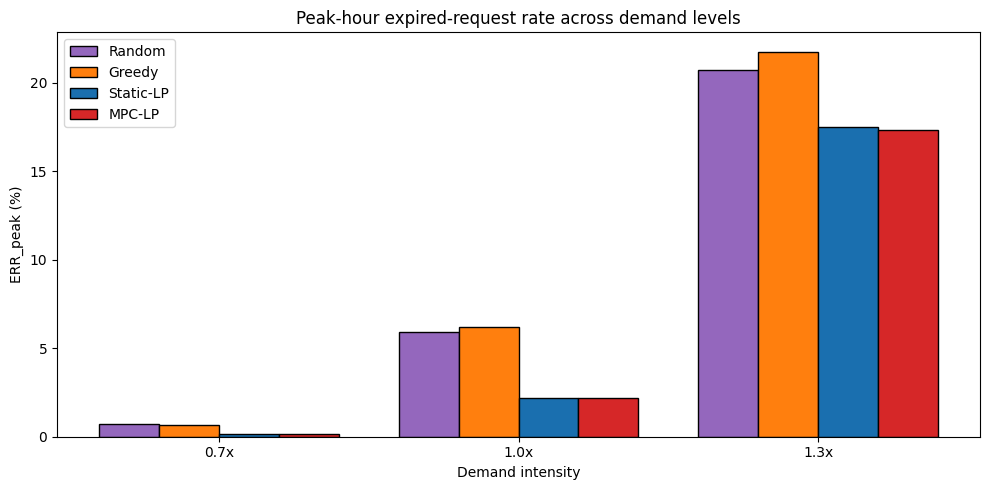

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = {"random": "#9467bd", "greedy": "#ff7f0e",
          "lp_static": "#1a6faf", "lp_mpc": "#d62728"}

xs = np.arange(len(demand_scales))
width = 0.20
for i, cid in enumerate(["random", "greedy", "lp_static", "lp_mpc"]):
    means = [results_by_demand[ds][cid]["ERR_peak"].mean() for ds in demand_scales]
    ax.bar(xs + (i - 1.5) * width, means, width,
           color=colors[cid], label=labels[cid], edgecolor="black")
ax.set_xticks(xs)
ax.set_xticklabels([f"{ds:.1f}x" for ds in demand_scales])
ax.set_xlabel("Demand intensity")
ax.set_ylabel("ERR_peak (%)")
ax.set_title("Peak-hour expired-request rate across demand levels")
ax.legend()
plt.tight_layout()
plt.show()

## Stage S Complete

**Outputs:** 12 result CSVs at `data/results/sim_results_{condition}_d{scale}.csv`

**Next:** Run `notebook_04_evaluation.ipynb` for the significance-focused evaluation.